
Processing folder: Pat03_W0
Density min: 9.24e-54, max: 8.22e-06, mean: 1.75e-06
T cells total: 435
T cells inside tumor region: 6
Infiltration ratio: 1.38%
T cells per tumor cell: 0.032
T cell density: 0.000
T cell fraction in tumor: 2.353%


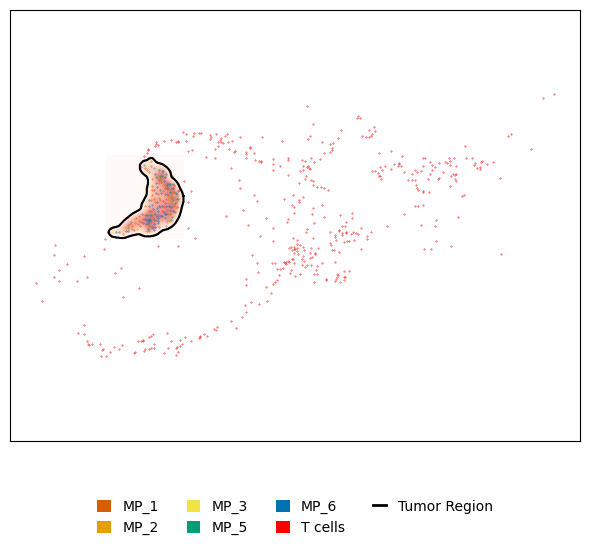


Processing folder: Pat03_W4
Density min: 0.00e+00, max: 4.21e-08, mean: 2.50e-09
T cells total: 12126
T cells inside tumor region: 5069
Infiltration ratio: 41.80%
T cells per tumor cell: 0.280
T cell density: 0.000
T cell fraction in tumor: 15.215%


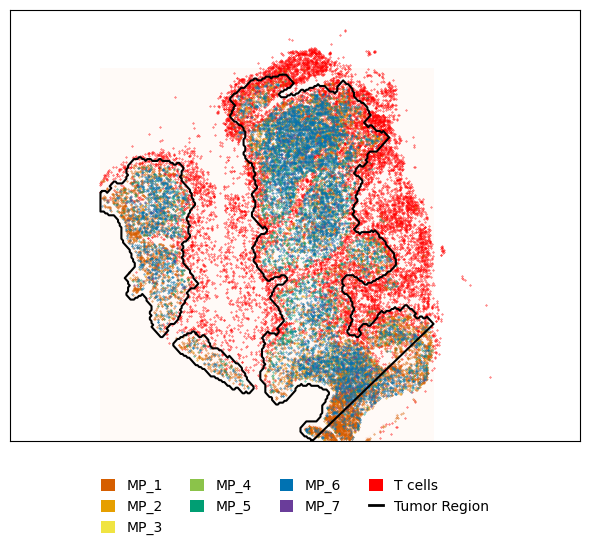


Processing folder: Pat06_W0
Not enough tumor or T cell points.

Processing folder: Pat06_W4
Density min: 0.00e+00, max: 1.59e-08, mean: 1.82e-09
T cells total: 2794
T cells inside tumor region: 1633
Infiltration ratio: 58.45%
T cells per tumor cell: 0.032
T cell density: 0.000
T cell fraction in tumor: 2.252%


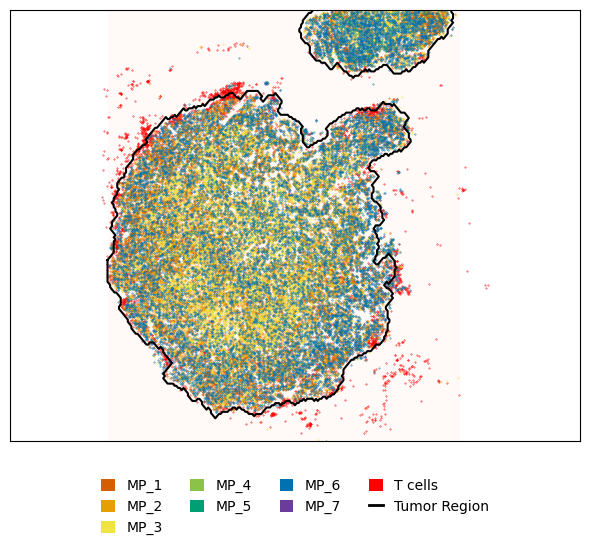


Processing folder: Pat14_W0
Density min: 0.00e+00, max: 1.11e-08, mean: 1.61e-09
T cells total: 23783
T cells inside tumor region: 23117
Infiltration ratio: 97.20%
T cells per tumor cell: 0.294
T cell density: 0.000
T cell fraction in tumor: 16.304%


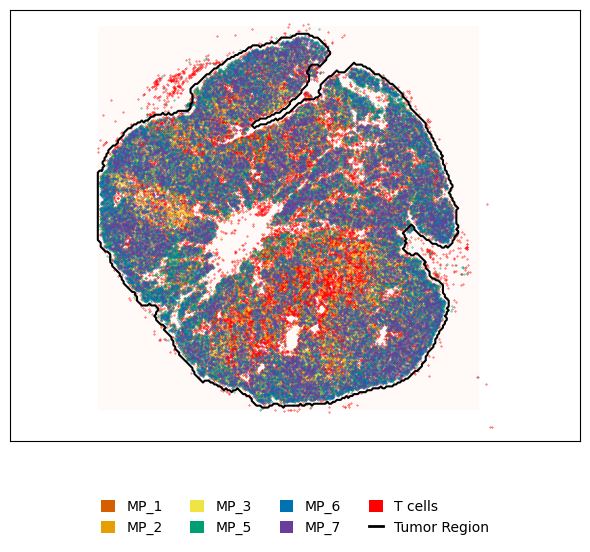


Processing folder: Pat14_W12
Density min: 0.00e+00, max: 7.91e-09, mean: 1.45e-09
T cells total: 28024
T cells inside tumor region: 26401
Infiltration ratio: 94.21%
T cells per tumor cell: 0.225
T cell density: 0.000
T cell fraction in tumor: 13.231%


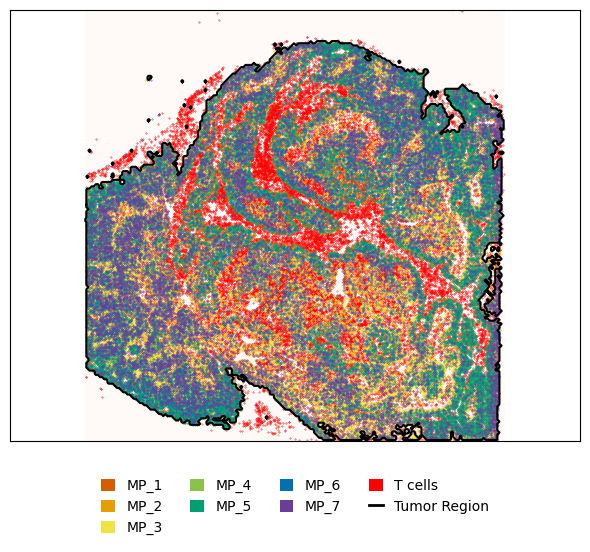


Processing folder: Pat14_W4
Density min: 0.00e+00, max: 5.49e-08, mean: 1.63e-09
T cells total: 5496
T cells inside tumor region: 1799
Infiltration ratio: 32.73%
T cells per tumor cell: 0.123
T cell density: 0.000
T cell fraction in tumor: 8.607%


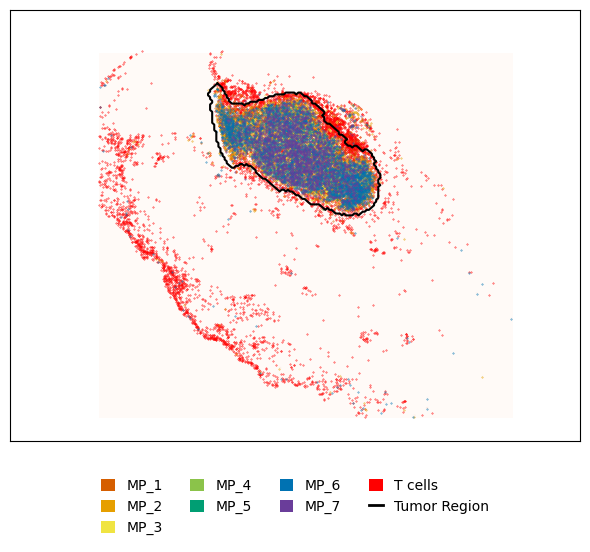


Processing folder: Pat2_W12
Density min: 0.00e+00, max: 2.37e-08, mean: 1.80e-09
T cells total: 4974
T cells inside tumor region: 1348
Infiltration ratio: 27.10%
T cells per tumor cell: 0.039
T cell density: 0.000
T cell fraction in tumor: 3.721%


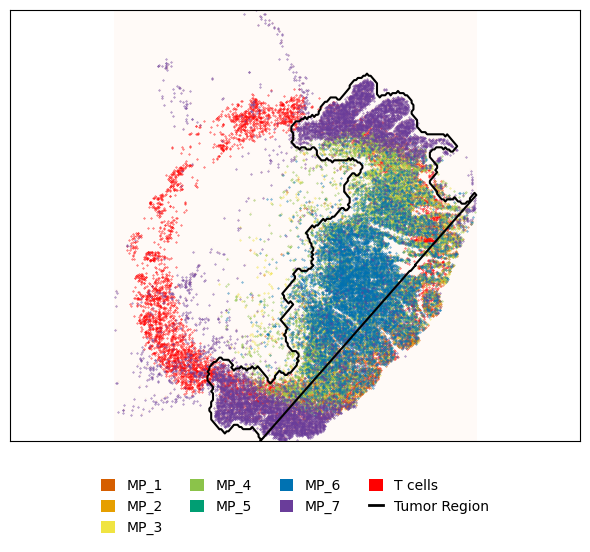


Processing folder: Pat2_W4
Density min: 0.00e+00, max: 3.58e-08, mean: 1.61e-09
T cells total: 971
T cells inside tumor region: 460
Infiltration ratio: 47.37%
T cells per tumor cell: 0.024
T cell density: 0.000
T cell fraction in tumor: 1.467%


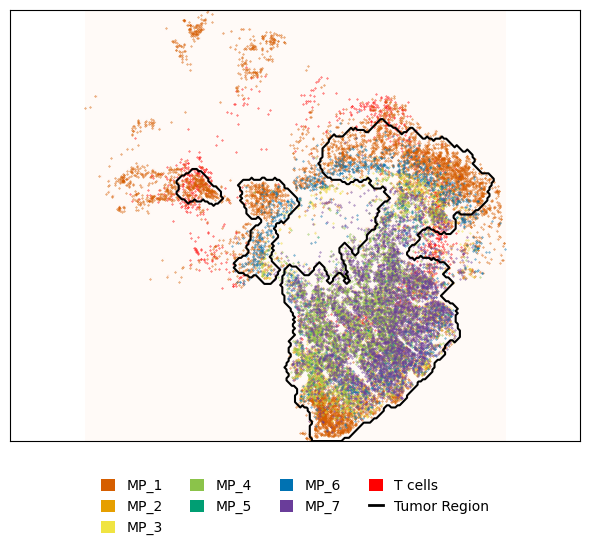

In [30]:
import os
import numpy as np
import pandas as pd
import anndata
from shapely.geometry import Point, Polygon
from sklearn.neighbors import KernelDensity
from skimage import morphology, measure
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt


cell_type_colors = {
    "B cells": "#e91e63",
    "Plasma cells": "#ce93d8",
    "T cells - CD4": "#673ab7",
    "T cells - CD4 Tcm": "#8B96D2",
    "T cells - CD8": "#61ABEC",
    "T cells - CD8 Tcm": "#02c1cf",
    "T cells - Exhausted T cell": "#BFEAEF",
    "T cells - Tregs": "#007991",
    "M1 macrophages": "#388e3c",
    "M2 macrophages": "#8bc34a",
    "iCAF": "#cddc39",
    "myoCAF": "#ffeb3b",
    "Endothelial cells": "#ffa407",
    "Keratinocytes": "#ff7043",
    "Malignant": "firebrick",
    "Cycling cells": "grey80",
    'MP_1': "#D55E00",
    'MP_2': "#E69F00",
    'MP_3': "#F0E442",
    'MP_4': "#8BC34A",
    'MP_5': "#009E73",
    'MP_6': "#0072B2",
    'MP_7': "#6A3D9A",
    "T cells": "#007991",
    "Macrophages": "#8bc34a",
    "CAF": "#ffeb3b",
}

# Set working directory
os.chdir('/home/fceccarelli/home3/OT_simulation/code/VisiumHD/segmentation')

# Get all relevant folders
folders = [x for x in os.listdir() if os.path.isdir(x) and x.startswith("Pat")]
folders.sort()
plot_MP = False
#folders = ["Pat06_W4", "Pat14_W0"]

results = []

for folder in folders:
    print(f"\nProcessing folder: {folder}")
    
    try:
        um = "008"
        adata = anndata.read_h5ad(folder + "/" + folder + "_" + um + "_programs.h5ad")
    except:
        print(f"Error reading {folder}")
        continue

    if "spatial" not in adata.obsm or "cell_type" not in adata.obs.columns:
        print("Missing spatial or cell_type information.")
        continue

    if (plot_MP):

        # Mask for MP_ and T cells
        mp_mask = adata.obs["cell_type"].str.startswith("MP_")
        tcell_mask = adata.obs["cell_type"].str.contains("T cells", case=False)
        combined_mask = mp_mask | tcell_mask

        # Extract spatial coordinates and cell types
        coords = adata.obsm["spatial"][combined_mask]
        cell_types = adata.obs.loc[combined_mask, "cell_type"]

        # Initialize figure
        plt.figure(figsize=(6, 6))

        for mp in sorted(cell_types.unique()):
            if mp.startswith("MP_3"):
                mp_mask = (adata.obs["cell_type"] == mp)
                mp_coords = adata.obsm["spatial"][mp_mask]
                plt.scatter(mp_coords[:, 0], mp_coords[:, 1], s=0.1, label=mp, color=cell_type_colors.get(mp, "gray"))

        # Plot all T cells in red
        t_coords = adata.obsm["spatial"][tcell_mask]
        plt.scatter(t_coords[:, 0], t_coords[:, 1], s=0.1, label="T cells", color="red")

        # Final touches
        plt.gca().invert_yaxis()
        plt.axis("equal")
        plt.xticks([])
        plt.yticks([])
        plt.title(f"MP and T cells in {folder}")

        # Custom legend
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=cell_type_colors.get(mp, 'gray'), label=mp) for mp in sorted(cell_types[mp_mask].unique())]
        legend_elements.append(Patch(facecolor='red', label='T cells'))

        plt.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=4, frameon=False)
        plt.tight_layout(rect=[0, 0.05, 1, 1])
        plt.show()


    tumor_mask = adata.obs["cell_type"].str.startswith("MP_")
    tcell_mask = adata.obs["cell_type"].str.contains("T cells", case=False)

    tumor_coords = adata.obsm["spatial"][tumor_mask]
    tcell_coords = adata.obsm["spatial"][tcell_mask]

    if len(tumor_coords) < 10 or len(tcell_coords) == 0:
        print("Not enough tumor or T cell points.")
        results.append({
            "patient_timepoint": folder, 
            "n_tumor_cells": len(tumor_coords),
            "n_tcells_total": 0,
            "n_tcells_inside": 0,
            "infiltration_ratio": 0,
            "infiltration_per_tumor_cell": 0,
            "infiltration_density": 0
        })
        continue

    # KDE
    tumor_x, tumor_y = tumor_coords[:, 0], tumor_coords[:, 1]
    padding = 50
    x_min, x_max = tumor_x.min() - padding, tumor_x.max() + padding
    y_min, y_max = tumor_y.min() - padding, tumor_y.max() + padding
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid_coords = np.vstack([xx.ravel(), yy.ravel()]).T

    kde = KernelDensity(bandwidth=30)
    kde.fit(tumor_coords)
    log_density = kde.score_samples(grid_coords)
    density = np.exp(log_density).reshape(xx.shape)

    print(f"Density min: {density.min():.2e}, max: {density.max():.2e}, mean: {density.mean():.2e}")

    # Threshold and morphology
    if (folder == "Pat03_W4"): binary_mask = density > (density.mean() * 0.01) 
    else: binary_mask = density > (density.mean() * 0.5)  

    cleaned = morphology.remove_small_objects(binary_mask, min_size=100)
    cleaned = morphology.remove_small_holes(cleaned, area_threshold=100)
    closed = morphology.binary_closing(cleaned, morphology.disk(3))
    dilated = morphology.binary_dilation(closed, morphology.disk(2))

    if (folder == "Pat14_W12"):
        contours = measure.find_contours(binary_mask.astype(float), level=0.5)
    else:  
        contours = measure.find_contours(dilated.astype(float), level=0.5)
    
    if not contours:
        print("No valid contours after morphology.")
        continue

    from shapely.ops import unary_union

    # Convert all contours into polygons
    polygons = []
    for contour in contours:
        contour_x = np.interp(contour[:, 1], np.arange(xx.shape[1]), xx[0])
        contour_y = np.interp(contour[:, 0], np.arange(yy.shape[0]), yy[:, 0])
        poly = Polygon(zip(contour_x, contour_y))
        if poly.is_valid and not poly.is_empty and poly.area > 100:  # Filter tiny/noisy ones
            polygons.append(poly)

    if not polygons:
        print("No valid tumor polygons.")
        continue

    # Combine all valid polygons into a MultiPolygon or union
    tumor_region = unary_union(polygons)

    # T cell analysis
    n_total_tcells = len(tcell_coords)
    n_tcells_inside = sum(tumor_region.contains(Point(x, y)) for x, y in tcell_coords)


    infiltration_ratio = n_tcells_inside / n_total_tcells
    infiltration_per_tumor_cell = n_tcells_inside / len(tumor_coords)
    infiltration_density = n_tcells_inside / tumor_region.area
    # All cells inside tumor region
    all_coords = adata.obsm["spatial"]
    n_cells_inside_tumor = sum(
        tumor_region.covers(Point(x, y)) for x, y in all_coords
    )

    # New metric
    tcell_fraction_in_tumor = (
        n_tcells_inside / n_cells_inside_tumor
        if n_cells_inside_tumor > 0 else 0
    )

    print(f"T cells total: {n_total_tcells}")
    print(f"T cells inside tumor region: {n_tcells_inside}")
    print(f"Infiltration ratio: {infiltration_ratio:.2%}")
    print(f"T cells per tumor cell: {infiltration_per_tumor_cell:.3f}")
    print(f"T cell density: {infiltration_density:.3f}")
    print(f"T cell fraction in tumor: {tcell_fraction_in_tumor:.3%}")

    # Plot
    plt.figure(figsize=(6, 6))
    plt.imshow(density, extent=(x_min, x_max, y_min, y_max), origin='lower', cmap='Reds', alpha=0.5)
    if tumor_region.geom_type == 'Polygon':
        x_poly, y_poly = tumor_region.exterior.xy
        plt.plot(x_poly, y_poly, color='black', label='Tumor Region')
    elif tumor_region.geom_type == 'MultiPolygon':
        for i, poly in enumerate(tumor_region.geoms):
            x_poly, y_poly = poly.exterior.xy
            plt.plot(x_poly, y_poly, color='black', label='Tumor Region' if i == 0 else None)

    plt.scatter(tcell_coords[:, 0], tcell_coords[:, 1], s=0.1, color="red", label='T cells')
    # Plot tumor cells colored by metaprogram
    tumor_celltypes = adata.obs.loc[tumor_mask, 'cell_type']
    tumor_spatial = adata.obsm["spatial"][tumor_mask]

    for mp in sorted(tumor_celltypes.unique()):
        if not mp.startswith("MP_"):
            continue  # Skip non-metaprogram labels
        mp_coords = tumor_spatial[tumor_celltypes == mp]
        plt.scatter(mp_coords[:, 0], mp_coords[:, 1], s=0.1, color=cell_type_colors.get(mp, 'gray'), label=mp)

    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    # Legend handles and labels
    handles = []
    labels = []

    # Tumor metaprograms (squares without black edge)
    for mp in sorted(tumor_celltypes.unique()):
        if mp.startswith("MP_"):
            color = cell_type_colors.get(mp, "gray")
            handles.append(Patch(facecolor=color))  # Removed edgecolor
            labels.append(mp)

    # T cells (red square without black edge)
    handles.append(Patch(facecolor="red"))
    labels.append("T cells")

    # Tumor Region (black line)
    handles.append(Line2D([0], [0], color='black', lw=2))
    labels.append("Tumor Region")

    # Create legend
    plt.legend(
        handles=handles,
        labels=labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.25),
        ncol=4,
        frameon=False,
        handleheight=1,
        handlelength=1,
        labelspacing=0.5,
        borderpad=0.5
    )
    plt.axis('equal')
    plt.xticks([]) 
    plt.yticks([])

    plt.tight_layout(rect=[0, 0.05, 1, 1])  # leave space at the bottom

    # Save as PDF
    output_path = f"{folder}_tcell_infiltration.pdf"
    plt.savefig(output_path, format='pdf', dpi=300, bbox_inches='tight')

    # Show the plot
    plt.show()

    results.append({
    "patient_timepoint": folder,
    "n_tumor_cells": len(tumor_coords),
    "n_cells_inside_tumor": n_cells_inside_tumor,
    "n_tcells_total": n_total_tcells,
    "n_tcells_inside": n_tcells_inside,
    "infiltration_ratio": infiltration_ratio,
    "infiltration_per_tumor_cell": infiltration_per_tumor_cell,
    "tcell_fraction_in_tumor": tcell_fraction_in_tumor,
    "infiltration_density": infiltration_density
})


# Summary dataframe
df_infiltration = pd.DataFrame(results)
df_infiltration[['patient', 'week']] = df_infiltration['patient_timepoint'].str.extract(r"(Pat\d+)_?(W\d+)")
df_infiltration['patient'] = df_infiltration['patient'].str.replace(r"Pat(\d+)", lambda m: f"Pat{int(m.group(1)):02}", regex=True)

responders = {"Pat03", "Pat14"}
non_responders = {"Pat02", "Pat06"}

def get_status(patient):
    if patient in responders:
        return "Responder"
    elif patient in non_responders:
        return "Non-Responder"
    else:
        return "Unknown"

df_infiltration['responder_status'] = df_infiltration['patient'].apply(get_status)

# Sort weeks for plotting
from pandas.api.types import CategoricalDtype
week_order = sorted(df_infiltration['week'].dropna().unique(), key=lambda x: int(x[1:]))
df_infiltration['week'] = df_infiltration['week'].astype(CategoricalDtype(categories=week_order, ordered=True))

grouped = df_infiltration.groupby(
    ['week', 'responder_status']
).agg({
    'infiltration_ratio': ['mean', 'std'],
    'infiltration_per_tumor_cell': ['mean', 'std'],
    'infiltration_density': ['mean', 'std'],
    'tcell_fraction_in_tumor': ['mean', 'std']  
}).reset_index()

grouped.columns = [
    'week', 'responder_status',
    'infiltration_ratio_mean', 'infiltration_ratio_std',
    'infiltration_per_tumor_cell_mean', 'infiltration_per_tumor_cell_std',
    'infiltration_density_mean', 'infiltration_density_std',
    'tcell_fraction_in_tumor_mean', 'tcell_fraction_in_tumor_std' 
]

/tmp/ipykernel_13736/1522662462.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtered = df_filtered[~((df_infiltration['patient'] == 'Pat03') & (df_infiltration['week'] == 'W0'))]
/tmp/ipykernel_13736/1522662462.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_13736/1522662462.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


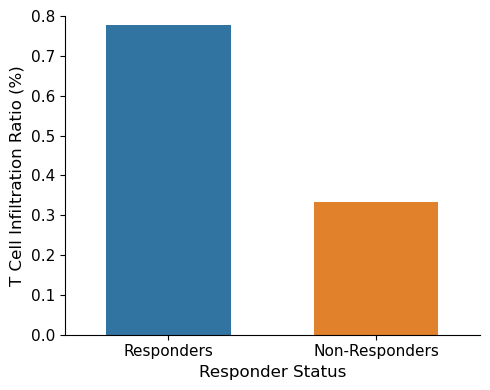

Mann–Whitney U test: U = 10.00, p = 0.2286


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu


# Filter to known responder status
df_filtered = df_infiltration[df_filtered['responder_status'].isin(["Responder", "Non-Responder"])]

# Rename for nicer x-axis labels
df_filtered['responder_status'] = df_filtered['responder_status'].replace({
    "Responder": "Responders",
    "Non-Responder": "Non-Responders"
})

# Choose metric to compare
metric = 'infiltration_ratio'
metric_label = 'T Cell Infiltration Ratio (%)'

# Perform statistical test
resp_vals = df_filtered[df_filtered['responder_status'] == "Responders"][metric]
nonresp_vals = df_filtered[df_filtered['responder_status'] == "Non-Responders"][metric]
stat, pval = mannwhitneyu(resp_vals, nonresp_vals, alternative='two-sided')

# Brighter color palette
bright_colors = ["#1f77b4", "#ff7f0e"]

# Plot
plt.figure(figsize=(5, 4))
ax = sns.barplot(
    data=df_filtered,
    x='responder_status',
    y=metric,
    ci=None,
    capsize=0.1,
    palette=bright_colors,
    width=0.6
)

# Y-axis limits
plt.ylim(0, 0.8)

# Titles and labels
plt.ylabel(metric_label, fontsize=12)
plt.xlabel("Responder Status", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Export as PDF
plt.tight_layout()
sns.despine()
#plt.savefig("infiltration_ratio_comparison.pdf", format='pdf', dpi=300)
plt.show()
print(f"Mann–Whitney U test: U = {stat:.2f}, p = {pval:.4g}")

/tmp/ipykernel_13736/42288193.py:27: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, pval = mannwhitneyu(resp_vals, nonresp_vals, alternative='two-sided')
/tmp/ipykernel_13736/42288193.py:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_13736/42288193.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


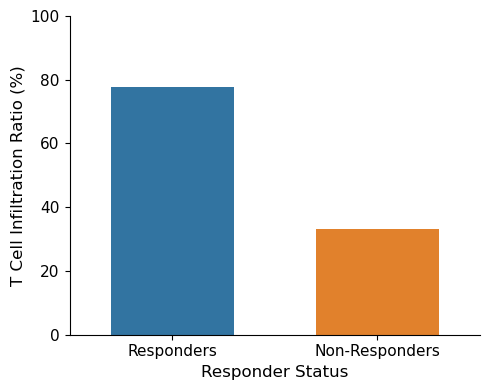

,patient_timepoint,n_tumor_cells,n_cells_inside_tumor,n_tcells_total,n_tcells_inside,infiltration_ratio,infiltration_per_tumor_cell,tcell_fraction_in_tumor,infiltration_density,patient,week,responder_status
1,Pat03_W4,18131,33316.0,12126,5069,41.802738,0.279576,0.152149,0.000032,Pat03,W4,Responders
2,Pat06_W0,32054,NaN,0,0,0.000000,0.000000,NaN,0.000000,Pat06,W0,Non-Responders
3,Pat06_W4,51276,72503.0,2794,1633,58.446671,0.031847,0.022523,0.000006,Pat06,W4,Non-Responders
4,Pat14_W0,78716,141788.0,23783,23117,97.199680,0.293676,0.163039,0.000057,Pat14,W0,Responders
5,Pat14_W12,117599,199546.0,28024,26401,94.208536,0.224500,0.132305,0.000053,Pat14,W12,Responders
7,Pat2_W12,34401,36226.0,4974,1348,27.100925,0.039185,0.037211,0.000012,Pat02,W12,Non-Responders
8,Pat2_W4,19322,31355.0,971,460,47.373841,0.023807,0.014671,0.000003,Pat02,W4,Non-Responders


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Filter to known responder status
df_filtered = df_infiltration[df_filtered['responder_status'].isin(["Responder", "Non-Responder"])]

# Rename for nicer x-axis labels
df_filtered['responder_status'] = df_filtered['responder_status'].replace({
    "Responder": "Responders",
    "Non-Responder": "Non-Responders"
})

# Choose metric to compare
metric = 'infiltration_ratio'
metric_label = 'T Cell Infiltration Ratio (%)'

df_filtered[metric] = df_filtered[metric] * 100

# Perform statistical test
resp_vals = df_filtered[df_filtered['responder_status'] == "Responder"][metric]
nonresp_vals = df_filtered[df_filtered['responder_status'] == "Non-Responder"][metric]
stat, pval = mannwhitneyu(resp_vals, nonresp_vals, alternative='two-sided')

# Brighter color palette
bright_colors = ["#1f77b4", "#ff7f0e"]

# Plot
plt.figure(figsize=(5, 4))
ax = sns.barplot(
    data=df_filtered,
    x='responder_status',
    y=metric,
    ci=None,
    capsize=0.1,
    palette=bright_colors,
    width=0.6
)

# Y-axis limits
plt.ylim(0, 100)

# Titles and labels
plt.ylabel(metric_label, fontsize=12)
plt.xlabel("Responder Status", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Export as PDF
plt.tight_layout()
sns.despine()
#plt.savefig("infiltration_ratio_comparison.pdf", format='pdf', dpi=300)
plt.show()
df_filtered

Mann–Whitney U p-value: 0.05714


/tmp/ipykernel_17296/181347004.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


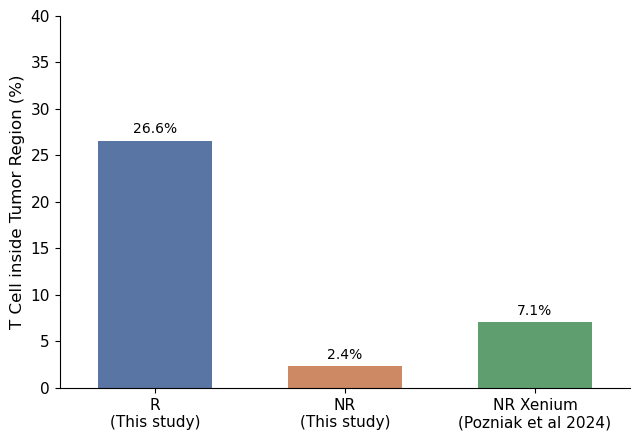

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# --------------------------------------------------
# 1. Filter and prepare data
# --------------------------------------------------

# Keep only known responder status
df_filtered = df_infiltration[
    df_filtered['responder_status'].isin(["Responder", "Non-Responder"])
]

# Metric of interest
metric = "infiltration_per_tumor_cell"  # fraction
df_filtered[metric] = df_filtered[metric] * 100  # convert to %

# --------------------------------------------------
# 2. Statistical test (Responders vs Non-Responders)
# --------------------------------------------------

resp_vals = df_filtered[df_filtered["responder_status"] == "Responder"][metric]
nonresp_vals = df_filtered[df_filtered["responder_status"] == "Non-Responder"][metric]

stat, pval = mannwhitneyu(resp_vals, nonresp_vals, alternative="two-sided")
print(f"Mann–Whitney U p-value: {pval:.4g}")

# --------------------------------------------------
# 3. Build plotting dataframe (explicit means)
# --------------------------------------------------

plot_df = pd.DataFrame({
    "Group": [
        "R\n(This study)",
        "NR\n(This study)",
        "NR Xenium\n(Pozniak et al 2024)"
    ],
    "Value": [
        resp_vals.mean(),
        nonresp_vals.mean(),
        7.088164905516685  # Xenium value
    ]
})

# --------------------------------------------------
# 4. Plot
# --------------------------------------------------

# Nice, clean color palette
palette = {
    "R\n(This study)": "#4C72B0",          # muted blue
    "NR\n(This study)": "#DD8452",         # muted orange
    "NR Xenium\n(Pozniak et al 2024)": "#55A868" # muted green
}

plt.figure(figsize=(6.5, 4.5))

ax = sns.barplot(
    data=plot_df,
    x="Group",
    y="Value",
    palette=palette,
    width=0.6
)

# Axis formatting
plt.ylabel("T Cell inside Tumor Region (%)", fontsize=12)
plt.xlabel("")
plt.ylim(0, 40)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Annotate bars with values
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.1f}%",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points"
    )

sns.despine()
plt.tight_layout()

# Uncomment to save
plt.savefig("tcell_inside_tumor_comparison_pozniak.pdf", dpi=300, bbox_inches="tight")

plt.show()